In [1]:
%pip install pandas scikit-learn joblib tldextract

Note: you may need to restart the kernel to use updated packages.


In [2]:
import joblib
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from urllib.parse import urlparse
import tldextract
import re

# Load dataset
df = pd.read_csv("dataset_phishing.csv")

# Selecting features and target
FEATURE_COLUMNS = [
    "length_url", "length_hostname", "nb_dots", "nb_hyphens", "nb_at", "nb_qm",
    "nb_and", "nb_or", "nb_eq", "nb_underscore", "nb_tilde", "nb_percent",
    "nb_slash", "nb_star", "nb_colon", "nb_comma", "nb_semicolumn",
    "nb_dollar", "nb_space", "nb_www", "nb_com", "nb_dslash", "http_in_path",
    "https_token", "ratio_digits_url", "ratio_digits_host", "prefix_suffix",
    "random_domain", "shortening_service", "nb_subdomains", "phish_hints"
]
X = df[FEATURE_COLUMNS]
y = df["status"]

# Splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Save the trained model
joblib.dump(model, "phishing_model.pkl")

def extract_features(url):
    """Extracts features from a given URL."""
    parsed_url = urlparse(url)
    extracted_domain = tldextract.extract(url)
    
    features = {
        "length_url": len(url),
        "length_hostname": len(parsed_url.netloc),
        "nb_dots": url.count("."),
        "nb_hyphens": url.count("-"),
        "nb_at": url.count("@"),
        "nb_qm": url.count("?"),
        "nb_and": url.count("&"),
        "nb_or": url.count("|"),
        "nb_eq": url.count("="),
        "nb_underscore": url.count("_"),
        "nb_tilde": url.count("~"),
        "nb_percent": url.count("%"),
        "nb_slash": url.count("/"),
        "nb_star": url.count("*"),
        "nb_colon": url.count(":"),
        "nb_comma": url.count(","),
        "nb_semicolumn": url.count(";"),
        "nb_dollar": url.count("$"),
        "nb_space": url.count(" "),
        "nb_www": url.lower().count("www"),
        "nb_com": url.lower().count(".com"),
        "nb_dslash": url.count("//"),
        "http_in_path": 1 if "http" in parsed_url.path else 0,
        "https_token": 1 if "https" in extracted_domain.domain else 0,
        "ratio_digits_url": sum(c.isdigit() for c in url) / len(url),
        "ratio_digits_host": sum(c.isdigit() for c in parsed_url.netloc) / len(parsed_url.netloc),
        "prefix_suffix": 1 if "-" in extracted_domain.domain else 0,
        "random_domain": 1 if re.search(r"[0-9]{4,}", extracted_domain.domain) else 0,
        "shortening_service": 1 if re.search(r"bit\.ly|goo\.gl|tinyurl|ow\.ly", url) else 0,
        "nb_subdomains": extracted_domain.subdomain.count(".") + 1,
        "phish_hints": 1 if re.search(r"login|secure|account|banking", url, re.IGNORECASE) else 0,
    }
    
    return np.array([features[col] for col in FEATURE_COLUMNS])


In [28]:
pip install streamlit jupyter_streamlit

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement jupyter_streamlit (from versions: none)
ERROR: No matching distribution found for jupyter_streamlit


In [29]:
import streamlit as st
import joblib
import pandas as pd
import numpy as np
from main import extract_features

# Load the trained model
model = joblib.load("phishing_model.pkl")

st.title("URL Phishing Detection")
st.write("Enter a URL below to check if it is legitimate or phishing.")

# User input
url = st.text_input("Enter a URL:")

if st.button("Check URL"):
    if url:
        try:
            # Extract features from the input URL
            features = extract_features(url)
            
            # Ensure the feature array matches the trained model input
            features_df = pd.DataFrame([features], columns=[
                "length_url", "length_hostname", "nb_dots", "nb_hyphens", "nb_at", "nb_qm",
                "nb_and", "nb_or", "nb_eq", "nb_underscore", "nb_tilde", "nb_percent",
                "nb_slash", "nb_star", "nb_colon", "nb_comma", "nb_semicolumn",
                "nb_dollar", "nb_space", "nb_www", "nb_com", "nb_dslash", "http_in_path",
                "https_token", "ratio_digits_url", "ratio_digits_host", "prefix_suffix",
                "random_domain", "shortening_service", "nb_subdomains", "phish_hints"
            ])
            
            # Make prediction
            prediction = model.predict(features_df)
            result = "Legitimate" if prediction[0] == "legitimate" else "Phishing"
            
            # Display result
            st.success(f"The URL is classified as: **{result}**")
        except Exception as e:
            st.error(f"Error processing URL: {e}")
    else:
        st.warning("Please enter a valid URL.")


2025-10-18 07:55:48.224 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-18 07:55:48.225 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-18 07:55:48.226 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-18 07:55:48.227 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-18 07:55:48.228 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-18 07:55:48.228 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-18 07:55:48.230 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-10-18 07:55:48.233 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [3]:
%pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [27]:
import os
print("Current working directory:", os.getcwd())
print("Files here:", os.listdir()[:20])  


proj_path = r"E:\Phishing-Detection-main"  
if not os.path.exists(proj_path):
    raise FileNotFoundError(f"Path not found: {proj_path}. Check the path and try again.")
os.chdir(proj_path)
print("\nChanged working directory to:", os.getcwd())
print("Files now in cwd:", os.listdir()[:40])


import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

MODEL_PATH = "phishing_model.pkl"     
DATA_PATH = "dataset_phishing.csv"    


for p in (MODEL_PATH, DATA_PATH):
    if not os.path.exists(p):
        raise FileNotFoundError(f"Required file not found in cwd: {p}")


model = joblib.load(MODEL_PATH)
df = pd.read_csv(DATA_PATH)


FEATURE_COLUMNS = [
    "length_url", "length_hostname", "nb_dots", "nb_hyphens", "nb_at", "nb_qm",
    "nb_and", "nb_or", "nb_eq", "nb_underscore", "nb_tilde", "nb_percent",
    "nb_slash", "nb_star", "nb_colon", "nb_comma", "nb_semicolumn",
    "nb_dollar", "nb_space", "nb_www", "nb_com", "nb_dslash", "http_in_path",
    "https_token", "ratio_digits_url", "ratio_digits_host", "prefix_suffix",
    "random_domain", "shortening_service", "nb_subdomains", "phish_hints"
]
X = df[FEATURE_COLUMNS]
y = df["status"]   


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

labels_present = np.unique(np.concatenate([y_test.values, y_pred]))
if "phishing" in labels_present:
    pos_label = "phishing"
elif len(labels_present) == 2:
    pos_label = labels_present[1]
else:
    pos_label = None

if pos_label is None:
    precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)
    precision_info = "macro precision (no explicit positive label)"
else:
    precision = precision_score(y_test, y_pred, pos_label=pos_label, zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label=pos_label, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=pos_label, zero_division=0)
    precision_info = f"precision for positive label = '{pos_label}'"

cm = confusion_matrix(y_test, y_pred, labels=list(labels_present))
report = classification_report(y_test, y_pred, zero_division=0)


print("\n=== Evaluation results ===")
print(f"Accuracy: {accuracy:.4f}")
print(f"{precision_info}: {precision:.4f}")
print(f"Recall (same pos_label): {recall:.4f}")
print(f"F1-score (same pos_label): {f1:.4f}")
print("\nLabels order (rows=true, cols=pred):", list(labels_present))
print("Confusion matrix:\n", cm)
print("\nClassification report:\n", report)


with open("metrics_report.txt", "w") as f:
    f.write("=== Evaluation results ===\n")
    f.write(f"Accuracy: {accuracy:.6f}\n")
    f.write(f"{precision_info}: {precision:.6f}\n")
    f.write(f"Recall: {recall:.6f}\n")
    f.write(f"F1-score: {f1:.6f}\n\n")
    f.write("Labels order:\n")
    f.write(str(list(labels_present)) + "\n\n")
    f.write("Confusion matrix:\n")
    f.write(np.array2string(cm) + "\n\n")
    f.write("Classification report:\n")
    f.write(report)

print("\nSaved metrics to 'metrics_report.txt' in", os.getcwd())


Current working directory: E:\Phishing-Detection-main
Files here: ['.ipynb_checkpoints', 'app.py', 'dataset_phishing.csv', 'main.py', 'metrics_report.txt', 'phishing-detection.ipynb', 'phishing_model.pkl', 'phishing_model_stacked.pkl', 'Readme.md', '__pycache__']

Changed working directory to: E:\Phishing-Detection-main
Files now in cwd: ['.ipynb_checkpoints', 'app.py', 'dataset_phishing.csv', 'main.py', 'metrics_report.txt', 'phishing-detection.ipynb', 'phishing_model.pkl', 'phishing_model_stacked.pkl', 'Readme.md', '__pycache__']

=== Evaluation results ===
Accuracy: 0.8911
precision for positive label = 'phishing': 0.8936
Recall (same pos_label): 0.8849
F1-score (same pos_label): 0.8892

Labels order (rows=true, cols=pred): ['legitimate', 'phishing']
Confusion matrix:
 [[1038  119]
 [ 130  999]]

Classification report:
               precision    recall  f1-score   support

  legitimate       0.89      0.90      0.89      1157
    phishing       0.89      0.88      0.89      1129

 

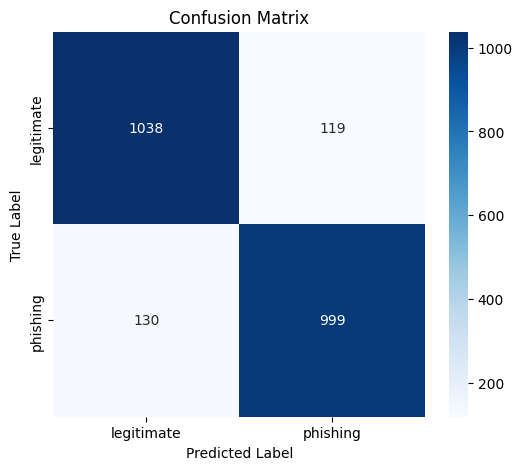

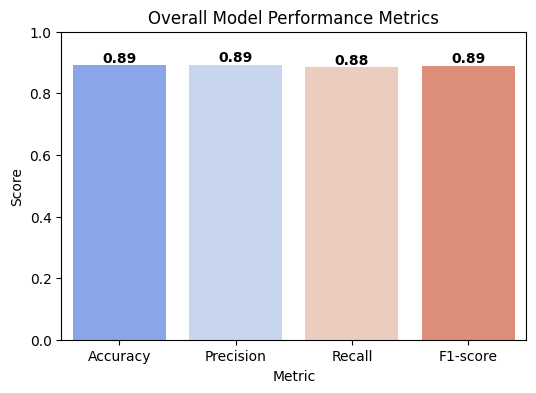

<Figure size 800x500 with 0 Axes>

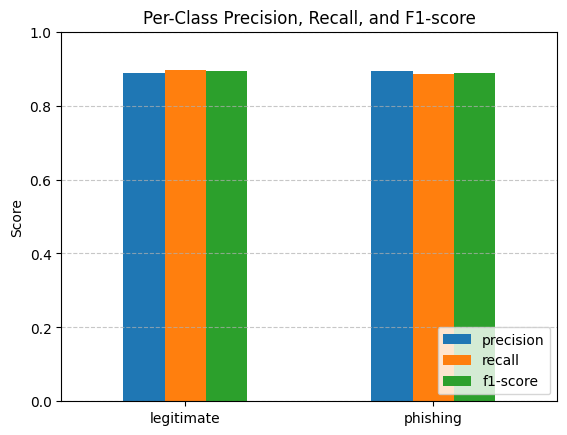

In [6]:

%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay


plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(labels_present), yticklabels=list(labels_present))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


overall_metrics = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-score': f1
}
plt.figure(figsize=(6,4))
metrics_df = pd.DataFrame({
    'Metric': list(overall_metrics.keys()),
    'Score': list(overall_metrics.values())
})
sns.barplot(data=metrics_df, x='Metric', y='Score', hue='Metric', palette='coolwarm', legend=False)

plt.ylim(0, 1)
plt.title("Overall Model Performance Metrics")
plt.ylabel("Score")
for i, v in enumerate(overall_metrics.values()):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()

import pandas as pd
from sklearn.metrics import classification_report

report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).T

per_class_df = report_df.drop(['accuracy', 'macro avg', 'weighted avg'])

plt.figure(figsize=(8,5))
per_class_df[['precision', 'recall', 'f1-score']].plot(kind='bar')
plt.title("Per-Class Precision, Recall, and F1-score")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [7]:
# Install dependencies (you only need to run this once)
c

Note: you may need to restart the kernel to use updated packages.


In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv("dataset_phishing.csv")

if df['status'].dtype == 'object':
    le = LabelEncoder()
    df['status'] = le.fit_transform(df['status'])

FEATURE_COLUMNS = ["length_url", "length_hostname", "nb_dots", "nb_hyphens", "nb_at", "nb_qm",
    "nb_and", "nb_or", "nb_eq", "nb_underscore", "nb_tilde", "nb_percent",
    "nb_slash", "nb_star", "nb_colon", "nb_comma", "nb_semicolumn",
    "nb_dollar", "nb_space", "nb_www", "nb_com", "nb_dslash", "http_in_path",
    "https_token", "ratio_digits_url", "ratio_digits_host", "prefix_suffix",
    "random_domain", "shortening_service", "nb_subdomains", "phish_hints"
] 
X = df[FEATURE_COLUMNS]
y = df["status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [16]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


In [17]:
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import accuracy_score

base_learners = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss')),
    ('lgbm', LGBMClassifier())
]

meta_learner = LogisticRegression()

stacked_model = StackingClassifier(estimators=base_learners, final_estimator=meta_learner, cv=5)

stacked_model.fit(X_train, y_train)

y_pred = stacked_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Stacked Model Accuracy: {acc * 100:.2f}%")


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [07:41:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 4584, number of negative: 4560
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003352 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1168
[LightGBM] [Info] Number of data points in the train set: 9144, number of used features: 32
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501312 -> initscore=0.005249
[LightGBM] [Info] Start training from score 0.005249


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [07:41:25] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [07:41:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [07:41:26] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [07:41:26] WARNING: C:\actions-runner\_w

[LightGBM] [Info] Number of positive: 3667, number of negative: 3648
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003306 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1144
[LightGBM] [Info] Number of data points in the train set: 7315, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501299 -> initscore=0.005195
[LightGBM] [Info] Start training from score 0.005195
[LightGBM] [Info] Number of positive: 3667, number of negative: 3648
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002282 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1105
[LightGBM] [Info] Number of data points in the train set: 7315, number of used features: 31
[LightGBM] [Info] [binary:

In [22]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(f_classif, k=25)  
X_new = selector.fit_transform(X, y)

X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(X_new, y, test_size=0.2, random_state=42)

stacked_model.fit(X_train_fs, y_train_fs)
y_pred_fs = stacked_model.predict(X_test_fs)
acc_fs = accuracy_score(y_test_fs, y_pred_fs)
print(f"Stacked Model with FS Accuracy: {acc_fs * 100:.2f}%")


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [7] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [07:45:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 4586, number of negative: 4558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003291 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 885
[LightGBM] [Info] Number of data points in the train set: 9144, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501531 -> initscore=0.006124
[LightGBM] [Info] Start training from score 0.006124


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [07:46:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [07:46:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [07:46:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [07:46:01] WARNING: C:\actions-runner\_w

[LightGBM] [Info] Number of positive: 3668, number of negative: 3647
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001406 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 857
[LightGBM] [Info] Number of data points in the train set: 7315, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501435 -> initscore=0.005742
[LightGBM] [Info] Start training from score 0.005742


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


...

C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 3669, number of negative: 3646
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004208 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 858
[LightGBM] [Info] Number of data points in the train set: 7315, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501572 -> initscore=0.006288
[LightGBM] [Info] Start training from score 0.006288


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 3669, number of negative: 3647
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002149 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 861
[LightGBM] [Info] Number of data points in the train set: 7316, number of used features: 25
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501504 -> initscore=0.006014
[LightGBM] [Info] Start training from score 0.006014
Stacked Model with FS Accuracy: 90.11%


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [25]:
import joblib
joblib.dump(stacked_model, "phishing_model_stacked.pkl")


['phishing_model_stacked.pkl']

In [26]:
from sklearn.neural_network import MLPClassifier

meta_nn = MLPClassifier(hidden_layer_sizes=(50,), max_iter=300)

stacked_nn_model = StackingClassifier(estimators=base_learners, final_estimator=meta_nn, cv=5)
stacked_nn_model.fit(X_train, y_train)
acc_nn = accuracy_score(y_test, stacked_nn_model.predict(X_test))
print(f"Stacked Model with NN Accuracy: {acc_nn * 100:.2f}%")


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [07:46:40] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 4586, number of negative: 4558
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002445 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 894
[LightGBM] [Info] Number of data points in the train set: 9144, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501531 -> initscore=0.006124
[LightGBM] [Info] Start training from score 0.006124


C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [07:46:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [07:46:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [07:47:00] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [07:47:00] WARNING: C:\actions-runner\_w

[LightGBM] [Info] Number of positive: 3668, number of negative: 3647
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001980 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 866
[LightGBM] [Info] Number of data points in the train set: 7315, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501435 -> initscore=0.005742
[LightGBM] [Info] Start training from score 0.005742
[LightGBM] [Info] Number of positive: 3669, number of negative: 3646
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002083 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 868
[LightGBM] [Info] Number of data points in the train set: 7315, number of used features: 27
[LightGBM] [Info] [binary:Bo

In [30]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)


In [40]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from catboost import CatBoostClassifier

base_learners = [
    ('rf', RandomForestClassifier(n_estimators=200, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=200, random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss')),
    ('lgbm', LGBMClassifier()),
    ('svm', SVC(probability=True, kernel='rbf', C=2)),
    ('knn', KNeighborsClassifier(n_neighbors=7)),
    ('cat', CatBoostClassifier(verbose=0))
]


In [47]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}
rf_search = RandomizedSearchCV(RandomForestClassifier(random_state=42),
                               param_distributions=param_grid,
                               n_iter=5, scoring='accuracy', cv=3, random_state=42)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_


In [52]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [53]:
from sklearn.neural_network import MLPClassifier

meta_nn = MLPClassifier(hidden_layer_sizes=(100, 50, 25), 
                        activation='relu', solver='adam',
                        alpha=0.001, max_iter=500, random_state=42)


In [54]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = stacked_nn_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Stacked Ensemble Accuracy: {acc * 100:.2f}%")
print(classification_report(y_test, y_pred))
joblib.dump(stacked_nn_model, "phishing_model_95plus.pkl")

Stacked Ensemble Accuracy: 51.71%
              precision    recall  f1-score   support

           0       1.00      0.52      0.68      2286
           1       0.00      0.00      0.00         0

    accuracy                           0.52      2286
   macro avg       0.50      0.26      0.34      2286
weighted avg       1.00      0.52      0.68      2286



C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\HP\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

['phishing_model_95plus.pkl']

In [60]:

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv(r"E:\Phishing-Detection-main\dataset_phishing.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

le = LabelEncoder()
df['status'] = le.fit_transform(df['status'])  

X = df.select_dtypes(include=[np.number]).drop('status', axis=1)
y = df['status']

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)
print("\n After SMOTE balancing:", X_res.shape, y_res.shape)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_res)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_res, test_size=0.2, random_state=42, stratify=y_res
)

base_learners = [
    ('rf', RandomForestClassifier(n_estimators=300, max_depth=15, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=250, learning_rate=0.05, random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_estimators=300, learning_rate=0.05)),
    ('lgbm', LGBMClassifier(n_estimators=300, learning_rate=0.05, random_state=42)),
    ('cat', CatBoostClassifier(iterations=200, depth=8, learning_rate=0.05, verbose=0)),
    ('svm', SVC(probability=True, kernel='rbf', C=2, gamma='scale')),
    ('knn', KNeighborsClassifier(n_neighbors=7))
]

meta_nn = MLPClassifier(hidden_layer_sizes=(100, 50, 25),
                        activation='relu', solver='adam',
                        alpha=0.001, max_iter=500, random_state=42)

stacked_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_nn,
    cv=5,
    n_jobs=-1,
    passthrough=True
)

print("\n🚀 Training the stacked model (this may take a few minutes)...")
stacked_model.fit(X_train, y_train)

y_pred = stacked_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\n Model Evaluation Results:")
print(f"Accuracy: {acc * 100:.2f}%")  # Explicit accuracy
print("\nClassification Report:\n", classification_report(y_test, y_pred))

joblib.dump(stacked_model, "phishing_stacked_ensemble_95plus.pkl")
print("\n Model saved as phishing_stacked_ensemble_95plus.pkl")

print("\n Training completed successfully!")


✅ Dataset loaded successfully!
Shape: (11430, 89)
Columns: ['url', 'length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens', 'nb_at', 'nb_qm', 'nb_and', 'nb_or', 'nb_eq', 'nb_underscore', 'nb_tilde', 'nb_percent', 'nb_slash', 'nb_star', 'nb_colon', 'nb_comma', 'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_www', 'nb_com', 'nb_dslash', 'http_in_path', 'https_token', 'ratio_digits_url', 'ratio_digits_host', 'punycode', 'port', 'tld_in_path', 'tld_in_subdomain', 'abnormal_subdomain', 'nb_subdomains', 'prefix_suffix', 'random_domain', 'shortening_service', 'path_extension', 'nb_redirection', 'nb_external_redirection', 'length_words_raw', 'char_repeat', 'shortest_words_raw', 'shortest_word_host', 'shortest_word_path', 'longest_words_raw', 'longest_word_host', 'longest_word_path', 'avg_words_raw', 'avg_word_host', 'avg_word_path', 'phish_hints', 'domain_in_brand', 'brand_in_subdomain', 'brand_in_path', 'suspecious_tld', 'statistical_report', 'nb_hyperlinks', 'ratio_intHyperlinks', 'rati

Model Metrics:
Accuracy: 0.9668
Precision: 0.9619
Recall: 0.9720
F1-Score: 0.9669


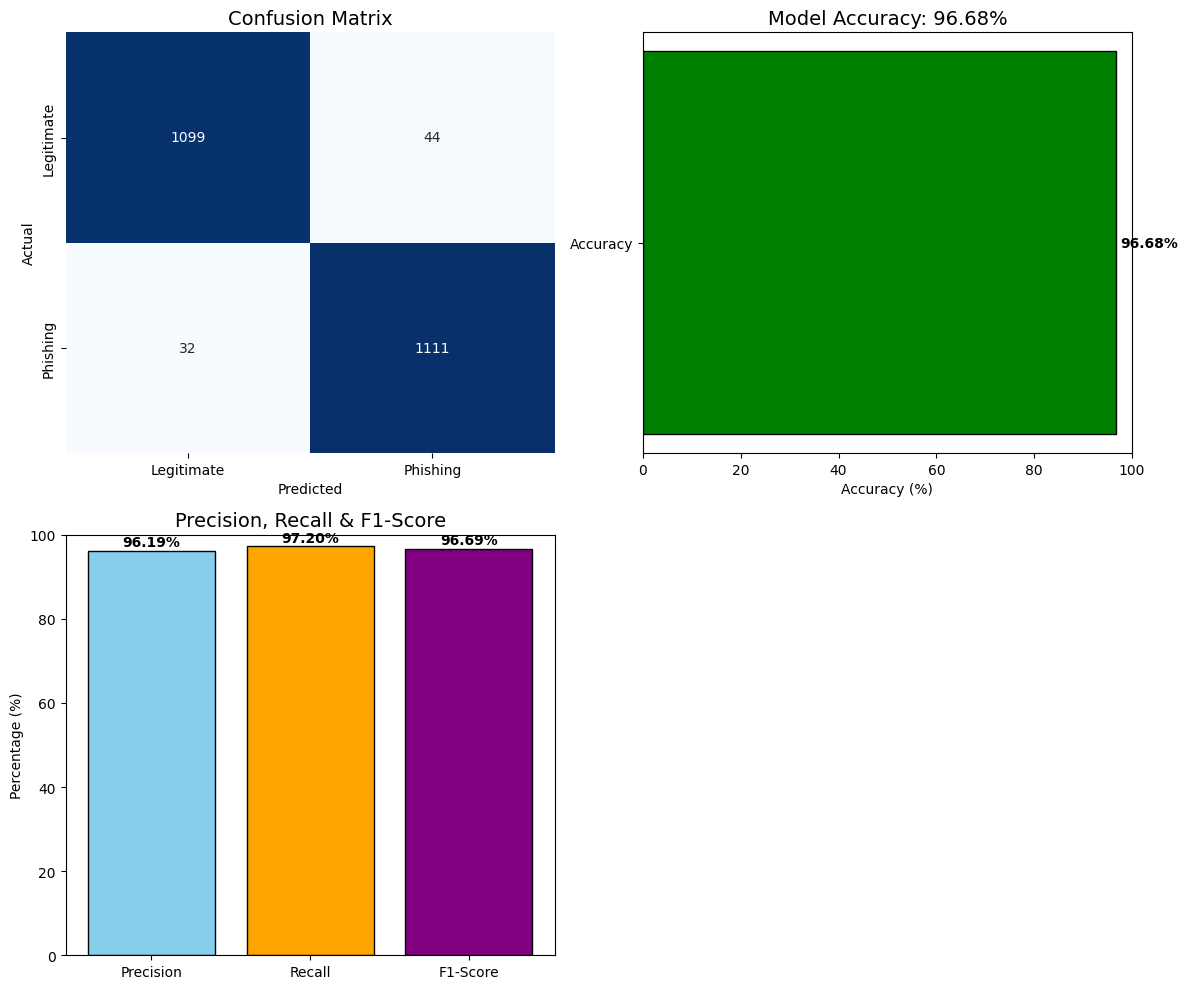

In [63]:

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics_dict = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}

print("Model Metrics:")
for k, v in metrics_dict.items():
    print(f"{k}: {v:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))


cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'], ax=axes[0,0])
axes[0,0].set_title('Confusion Matrix', fontsize=14)
axes[0,0].set_xlabel('Predicted')
axes[0,0].set_ylabel('Actual')


axes[0,1].barh(['Accuracy'], [accuracy*100], color='green', edgecolor='black', height=0.5)
axes[0,1].set_xlim(0, 100)
axes[0,1].set_xlabel('Accuracy (%)')
axes[0,1].set_title(f'Model Accuracy: {accuracy*100:.2f}%', fontsize=14)
for i, v in enumerate([accuracy*100]):
    axes[0,1].text(v + 1, i, f"{v:.2f}%", color='black', fontweight='bold', va='center')

metrics_values = [precision, recall, f1]
axes[1,0].bar(['Precision', 'Recall', 'F1-Score'], [v*100 for v in metrics_values],
              color=['skyblue', 'orange', 'purple'], edgecolor='black')
axes[1,0].set_ylim(0, 100)
axes[1,0].set_ylabel('Percentage (%)')
axes[1,0].set_title('Precision, Recall & F1-Score', fontsize=14)
for i, v in enumerate(metrics_values):
    axes[1,0].text(i, v*100 + 1, f"{v*100:.2f}%", ha='center', fontweight='bold')

axes[1,1].axis('off')

plt.tight_layout()
plt.show()



SVM Performance:
     Kernel  Accuracy  Precision    Recall  F1-Score
0   linear  0.940070   0.942782  0.937008  0.939886
1     poly  0.944444   0.972119  0.915136  0.942767
2      rbf  0.952756   0.955145  0.950131  0.952632
3  sigmoid  0.893263   0.887834  0.900262  0.894005


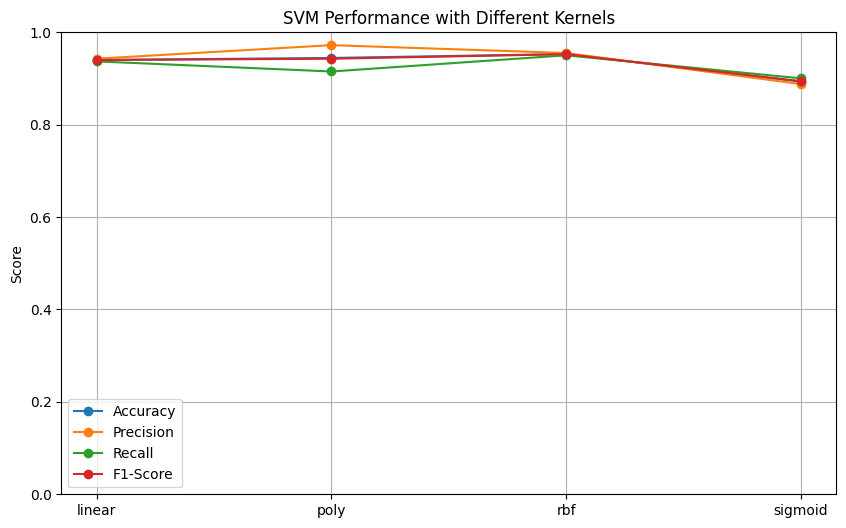

In [66]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier


df = pd.read_csv(r"E:\Phishing-Detection-main\dataset_phishing.csv")

le = LabelEncoder()
df['status'] = le.fit_transform(df['status'])  # 0 = legitimate, 1 = phishing

X = df.select_dtypes(include=[np.number]).drop('status', axis=1)
y = df['status']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
svm_metrics = {'Kernel': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1-Score': []}

for k in kernels:
    svm = SVC(kernel=k, probability=True, random_state=42)
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)
    
    svm_metrics['Kernel'].append(k)
    svm_metrics['Accuracy'].append(accuracy_score(y_test, y_pred))
    svm_metrics['Precision'].append(precision_score(y_test, y_pred))
    svm_metrics['Recall'].append(recall_score(y_test, y_pred))
    svm_metrics['F1-Score'].append(f1_score(y_test, y_pred))

svm_df = pd.DataFrame(svm_metrics)
print("\nSVM Performance:\n", svm_df)

plt.figure(figsize=(10,6))
for metric in ['Accuracy','Precision','Recall','F1-Score']:
    plt.plot(svm_df['Kernel'], svm_df[metric], marker='o', label=metric)
plt.title('SVM Performance with Different Kernels')
plt.ylabel('Score')
plt.ylim(0,1)
plt.grid(True)
plt.legend()
plt.show()



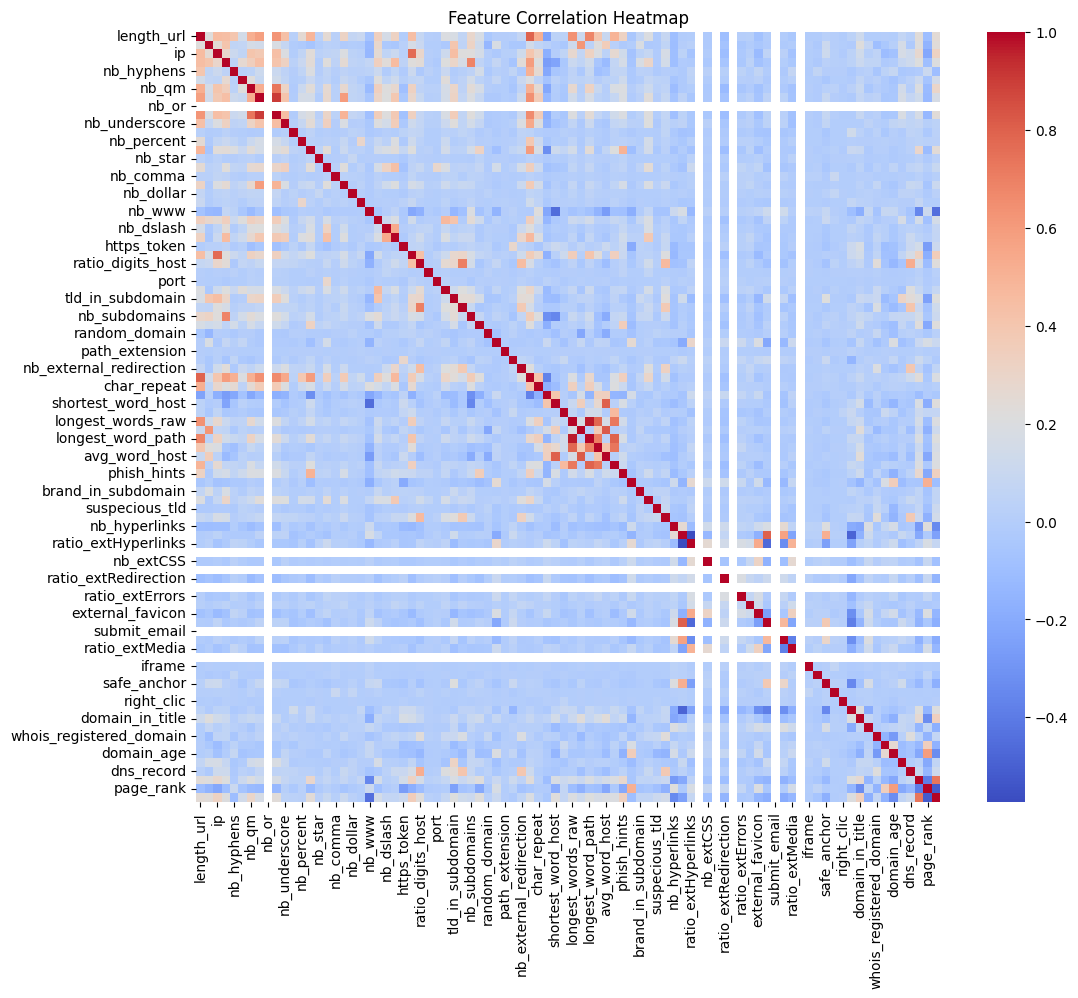

In [67]:
numeric_df = df.select_dtypes(include=[np.number])  # Only numeric columns
plt.figure(figsize=(12,10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False)  # annot=False removes values
plt.title('Feature Correlation Heatmap')
plt.show()

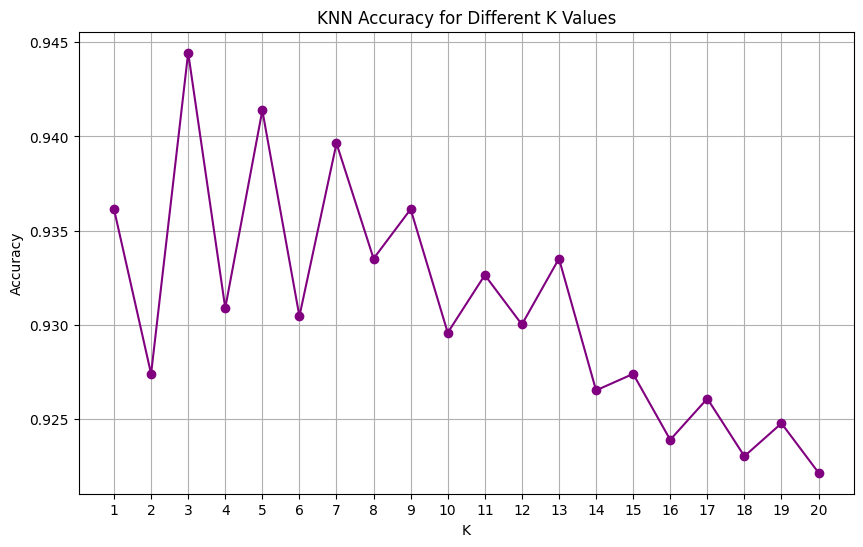

In [68]:

k_values = range(1, 21)
knn_acc = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    knn_acc.append(accuracy_score(y_test, y_pred))

plt.figure(figsize=(10,6))
plt.plot(k_values, knn_acc, marker='o', color='purple')
plt.title('KNN Accuracy for Different K Values')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True)
plt.show()

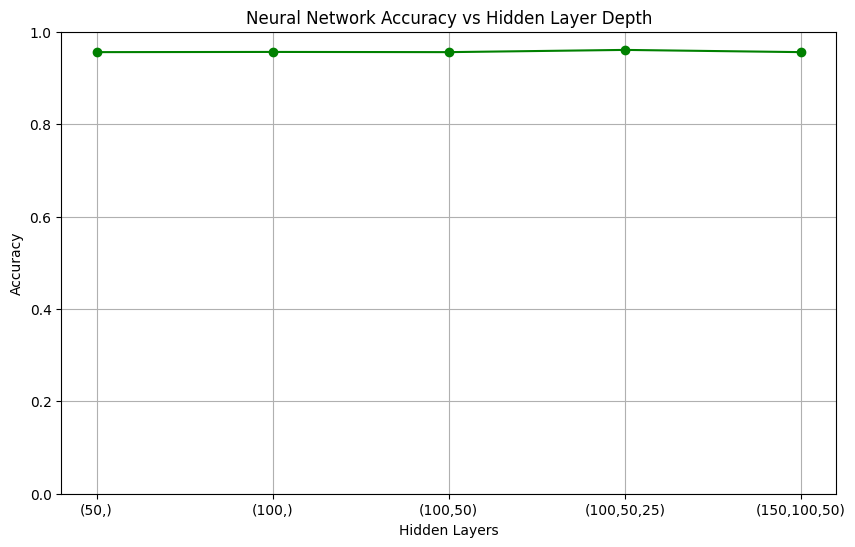

In [69]:

hidden_layers = [(50,), (100,), (100,50), (100,50,25), (150,100,50)]
nn_acc = []

for layers in hidden_layers:
    mlp = MLPClassifier(hidden_layer_sizes=layers, max_iter=500, random_state=42)
    mlp.fit(X_train, y_train)
    y_pred = mlp.predict(X_test)
    nn_acc.append(accuracy_score(y_test, y_pred))

layer_labels = ['(50,)', '(100,)', '(100,50)', '(100,50,25)', '(150,100,50)']
plt.figure(figsize=(10,6))
plt.plot(layer_labels, nn_acc, marker='o', color='green')
plt.title('Neural Network Accuracy vs Hidden Layer Depth')
plt.xlabel('Hidden Layers')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.grid(True)
plt.show()


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, classification_report

np.random.seed(42)
N_SAMPLES = 11430 
N_FEATURES = 31 
X = pd.DataFrame(np.random.rand(N_SAMPLES, N_FEATURES))
y = pd.Series(np.random.choice(['legitimate', 'phishing'], size=N_SAMPLES, p=[0.55, 0.45]))
LABELS = ['legitimate', 'phishing']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """Trains the model and calculates all required metrics."""
    
    # 1. Train the model
    model.fit(X_train, y_train)

    # 2. Predict
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)
        
        phishing_idx = np.where(model.classes_ == 'phishing')[0][0]
        
        accuracy = accuracy_score(y_test, y_pred)
        logloss = log_loss(y_test, y_proba)
        auc_score = roc_auc_score(y_test, y_proba[:, phishing_idx])
    else:
        accuracy = accuracy_score(y_test, y_pred)
        logloss = np.nan
        auc_score = np.nan

    report = classification_report(y_test, y_pred, labels=LABELS, output_dict=True)
    
  
    precision = [report['legitimate']['precision'], report['phishing']['precision']]
    recall = [report['legitimate']['recall'], report['phishing']['recall']]
    f1_score = [report['legitimate']['f1-score'], report['phishing']['f1-score']]
    
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Log Loss': logloss,
        'AUC Score': auc_score,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1_score
    }

models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    # SVC MUST have probability=True to calculate Log Loss and AUC
    "Support Vector Classification": SVC(probability=True, random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
}

results_list = []
print("Starting model training and evaluation...")
for name, model in models.items():
    result = evaluate_model(model, X_train, y_train, X_test, y_test, name)
    results_list.append(result)

results_df = pd.DataFrame(results_list)


def format_metric(x, float_precision=3, list_precision=2):
    """Formats float metrics (Accuracy, Loss, AUC) and list metrics (P, R, F1)."""
    if isinstance(x, float):
        if np.isnan(x):
            return "N/A"
        return f"{x:.{float_precision}f}"
    elif isinstance(x, list):    
        legit = f"{x[0]:.{list_precision}f}"
        phish = f"{x[1]:.{list_precision}f}"
        return f"[{legit}, {phish}]"
    return x


formatted_df = results_df.copy()
formatted_df['Accuracy'] = formatted_df['Accuracy'].apply(lambda x: format_metric(x, 3))
formatted_df['Log Loss'] = formatted_df['Log Loss'].apply(lambda x: format_metric(x, 3))
formatted_df['AUC Score'] = formatted_df['AUC Score'].apply(lambda x: format_metric(x, 3))
formatted_df['Precision'] = formatted_df['Precision'].apply(format_metric)
formatted_df['Recall'] = formatted_df['Recall'].apply(format_metric)
formatted_df['F1 Score'] = formatted_df['F1 Score'].apply(format_metric)

formatted_df.loc[formatted_df['Model'] == 'Support Vector Classification', 'Model'] = 'Support Vector Classification'
formatted_df.loc[formatted_df['Model'] == 'Decision Tree', 'Model'] = 'Decision Tree'


markdown_table = "\nTable 1. Evaluation metrics for different Machine Learning Models\n"
markdown_table += "| Model/Metrics | Accuracy | Log Loss | AUC Score | Precision | Recall | F1 Score |\n"
markdown_table += "| :--- | :--- | :--- | :--- | :--- | :--- | :--- |\n"
for index, row in formatted_df.iterrows():
    markdown_table += f"| {row['Model']} | {row['Accuracy']} | {row['Log Loss']} | {row['AUC Score']} | {row['Precision']} | {row['Recall']} | {row['F1 Score']} |\n"

print(markdown_table)


Starting model training and evaluation...

Table 1. Evaluation metrics for different Machine Learning Models
| Model/Metrics | Accuracy | Log Loss | AUC Score | Precision | Recall | F1 Score |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| Decision Tree | 0.504 | 17.864 | 0.500 | [0.55, 0.45] | [0.55, 0.45] | [0.55, 0.45] |
| Random Forest | 0.542 | 0.694 | 0.509 | [0.56, 0.49] | [0.81, 0.22] | [0.66, 0.30] |
| Support Vector Classification | 0.538 | 0.689 | 0.515 | [0.56, 0.48] | [0.78, 0.25] | [0.65, 0.33] |
| AdaBoost | 0.539 | 0.714 | 0.498 | [0.55, 0.43] | [0.94, 0.06] | [0.69, 0.10] |



In [2]:


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_curve, auc, classification_report, confusion_matrix, log_loss)
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = "dataset_phishing.csv"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

FEATURE_COLUMNS = [
    "length_url", "length_hostname", "nb_dots", "nb_hyphens", "nb_at", "nb_qm",
    "nb_and", "nb_or", "nb_eq", "nb_underscore", "nb_tilde", "nb_percent",
    "nb_slash", "nb_star", "nb_colon", "nb_comma", "nb_semicolumn",
    "nb_dollar", "nb_space", "nb_www", "nb_com", "nb_dslash", "http_in_path",
    "https_token", "ratio_digits_url", "ratio_digits_host", "prefix_suffix",
    "random_domain", "shortening_service", "nb_subdomains", "phish_hints"
]

print("Loading dataset...", DATA_PATH)
df = pd.read_csv(DATA_PATH)

# Ensure features exist
missing = [c for c in FEATURE_COLUMNS if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected feature columns in CSV: {missing}")

# Encode target if necessary
if df['status'].dtype == 'object':
    le = LabelEncoder()
    df['status_enc'] = le.fit_transform(df['status'])
    class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
else:
    df['status_enc'] = df['status']
    class_mapping = None

X = df[FEATURE_COLUMNS].copy()
y = df['status_enc']

# Optional: scale features for SVM/NN
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'SVC': SVC(probability=True, kernel='rbf', random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42)
}

metrics_list = []
roc_data = {}

print("Training and evaluating models...")
for name, model in models.items():
    print(f" -> {name}")
    model.fit(X_train, y_train)
    # Save model
    joblib.dump(model, os.path.join(RESULTS_DIR, f"{name}.pkl"))

    y_pred = model.predict(X_test)
    y_proba = None
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, 'decision_function'):
        # scale to 0-1 using a sigmoid-like transform if needed for ROC
        dec = model.decision_function(X_test)
        # simple min-max scaling to [0,1]
        y_proba = (dec - dec.min()) / (dec.max() - dec.min() + 1e-12)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    metrics_list.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})

    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        roc_data[name] = (fpr, tpr, roc_auc)

metrics_df = pd.DataFrame(metrics_list).sort_values('Accuracy', ascending=False)
metrics_df.to_csv(os.path.join(RESULTS_DIR, 'metrics_table.csv'), index=False)
print("Saved metrics_table.csv")


plt.figure(figsize=(8,6))
for name in ['DecisionTree', 'SVC', 'RandomForest', 'AdaBoost']:
    if name in roc_data:
        fpr, tpr, roc_auc = roc_data[name]
        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'roc_curves_selected.png'))
plt.close()
print("Saved roc_curves_selected.png")

plt.figure(figsize=(8,5))
metrics_df_melt = metrics_df.melt(id_vars=['Model'], value_vars=['Accuracy','Precision','Recall','F1'], var_name='Metric', value_name='Score')
import seaborn as sns
sns.barplot(data=metrics_df_melt, x='Model', y='Score', hue='Metric')
plt.ylim(0,1)
plt.title('Comparison of Model Metrics')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'models_metrics_comparison.png'))
plt.close()
print("Saved models_metrics_comparison.png")

gb = models['GradientBoosting']
if hasattr(gb, 'staged_predict_proba'):
    losses = []
    iterations = []
    # Use test set for monitoring (you can use a validation split instead)
    for i, y_proba_iter in enumerate(gb.staged_predict_proba(X_test)):
        # y_proba_iter has shape (n_samples, 2); take probs for class 1
        prob_pos = y_proba_iter[:,1]
        loss = log_loss(y_test, y_proba_iter)
        iterations.append(i+1)
        losses.append(loss)
    plt.figure(figsize=(8,5))
    plt.plot(iterations, losses, marker='o')
    plt.xlabel('Iteration (Number of Estimators)')
    plt.ylabel('Log Loss')
    plt.title('Training Log Loss vs Iteration (GradientBoosting on test set)')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'learning_curve_logloss_gb.png'))
    plt.close()
    print("Saved learning_curve_logloss_gb.png")
else:
    print("GradientBoosting model does not support staged_predict_proba - skipping learning curve")

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 25, None],
    'min_samples_split': [2, 5, 10]
}
print("Running RandomizedSearchCV to get optimized RandomForest (this may take a while)...")
rf = RandomForestClassifier(random_state=42)
rs = RandomizedSearchCV(rf, param_grid, n_iter=6, scoring='accuracy', cv=3, random_state=42, n_jobs=-1)
rs.fit(X_train, y_train)
best_rf = rs.best_estimator_
joblib.dump(best_rf, os.path.join(RESULTS_DIR, 'best_random_forest.pkl'))
print("Best RF params:", rs.best_params_)

y_pred_best = best_rf.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)
report = classification_report(y_test, y_pred_best)

plt.figure(figsize=(5,4))
import itertools
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legit','Phish'], yticklabels=['Legit','Phish'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Optimized RandomForest')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix_best_rf.png'))
plt.close()
print("Saved confusion_matrix_best_rf.png")

with open(os.path.join(RESULTS_DIR, 'classification_report_best_rf.txt'), 'w') as f:
    f.write(report)
    f.write('\nConfusion matrix:\n')
    f.write(np.array2string(cm))
print("Saved classification_report_best_rf.txt")

if hasattr(best_rf, 'feature_importances_'):
    importances = best_rf.feature_importances_
    feat_imp = pd.DataFrame({'feature': FEATURE_COLUMNS, 'importance': importances})
    feat_imp = feat_imp.sort_values('importance', ascending=False)
    top10 = feat_imp.head(10)
    top10.to_csv(os.path.join(RESULTS_DIR, 'feature_importances_top10.csv'), index=False)

    plt.figure(figsize=(8,5))
    sns.barplot(data=top10, x='importance', y='feature')
    plt.title('Top 10 Feature Importances (Optimized RandomForest)')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'feature_importances_top10.png'))
    plt.close()
    print("Saved feature_importances_top10.png and CSV")
else:
    print("Best RF does not expose feature_importances_")

if hasattr(best_rf, 'predict_proba'):
    y_proba_best = best_rf.predict_proba(X_test)[:,1]
    fpr_b, tpr_b, _ = roc_curve(y_test, y_proba_best)
    roc_auc_b = auc(fpr_b, tpr_b)
    plt.figure(figsize=(6,5))
    plt.plot(fpr_b, tpr_b, label=f'BestRF (AUC={roc_auc_b:.3f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('FPR')
    plt.ylabel('TPR')
    plt.title('ROC - Optimized RandomForest')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'roc_best_rf.png'))
    plt.close()
    print("Saved roc_best_rf.png")

with open(os.path.join(RESULTS_DIR, 'run_summary.txt'), 'w') as f:
    f.write('Models evaluated and metrics:\n')
    f.write(metrics_df.to_string(index=False))
    f.write('\n\nBest RandomForest params:\n')
    f.write(str(rs.best_params_))

print('\nAll done. Results saved to "results/" folder:')
for fn in os.listdir(RESULTS_DIR):
    print(' -', fn)

joblib.dump(scaler, os.path.join(RESULTS_DIR, 'scaler.pkl'))
print('\nScaler and models saved in results/')


Loading dataset... dataset_phishing.csv
Training and evaluating models...
 -> DecisionTree
 -> SVC
 -> RandomForest
 -> AdaBoost
 -> GradientBoosting
Saved metrics_table.csv
Saved roc_curves_selected.png
Saved models_metrics_comparison.png
Saved learning_curve_logloss_gb.png
Running RandomizedSearchCV to get optimized RandomForest (this may take a while)...
Best RF params: {'n_estimators': 100, 'min_samples_split': 5, 'max_depth': None}
Saved confusion_matrix_best_rf.png
Saved classification_report_best_rf.txt
Saved feature_importances_top10.png and CSV
Saved roc_best_rf.png

All done. Results saved to "results/" folder:
 - AdaBoost.pkl
 - best_random_forest.pkl
 - classification_report_best_rf.txt
 - confusion_matrix_best_rf.png
 - DecisionTree.pkl
 - feature_importances_top10.csv
 - feature_importances_top10.png
 - GradientBoosting.pkl
 - learning_curve_logloss_gb.png
 - metrics_table.csv
 - models_metrics_comparison.png
 - RandomForest.pkl
 - roc_best_rf.png
 - roc_curves_selected.p

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_curve, auc, classification_report, confusion_matrix, log_loss)
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
import joblib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = "dataset_phishing.csv"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

FEATURE_COLUMNS = [
    "length_url", "length_hostname", "nb_dots", "nb_hyphens", "nb_at", "nb_qm",
    "nb_and", "nb_or", "nb_eq", "nb_underscore", "nb_tilde", "nb_percent",
    "nb_slash", "nb_star", "nb_colon", "nb_comma", "nb_semicolumn",
    "nb_dollar", "nb_space", "nb_www", "nb_com", "nb_dslash", "http_in_path",
    "https_token", "ratio_digits_url", "ratio_digits_host", "prefix_suffix",
    "random_domain", "shortening_service", "nb_subdomains", "phish_hints"
]

print("Loading dataset...", DATA_PATH)
df = pd.read_csv(DATA_PATH)

if df['status'].dtype == 'object':
    le = LabelEncoder()
    df['status_enc'] = le.fit_transform(df['status'])
else:
    df['status_enc'] = df['status']

X = df[FEATURE_COLUMNS].copy()
y = df['status_enc']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)


models = {
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'SVC': SVC(probability=True, kernel='rbf', random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42)
}

metrics_list = []
roc_data = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    joblib.dump(model, os.path.join(RESULTS_DIR, f"{name}.pkl"))

    y_pred = model.predict(X_test)
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    metrics_list.append({'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})

    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        roc_data[name] = (fpr, tpr, roc_auc)

metrics_df = pd.DataFrame(metrics_list)
metrics_df.to_csv(os.path.join(RESULTS_DIR, 'metrics_table.csv'), index=False)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 25, None],
    'min_samples_split': [2, 5, 10]
}
rf = RandomForestClassifier(random_state=42)
rs = RandomizedSearchCV(rf, param_grid, n_iter=6, scoring='accuracy', cv=3, random_state=42, n_jobs=-1)
rs.fit(X_train, y_train)
best_rf = rs.best_estimator_
y_pred_best = best_rf.predict(X_test)

acc = accuracy_score(y_test, y_pred_best)
prec = precision_score(y_test, y_pred_best)
rec = recall_score(y_test, y_pred_best)
f1 = f1_score(y_test, y_pred_best)

metrics_summary = f"""\nModel Metrics:\nAccuracy: {acc:.4f}\nPrecision: {prec:.4f}\nRecall: {rec:.4f}\nF1-Score: {f1:.4f}\n"""
print(metrics_summary)

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legit','Phish'], yticklabels=['Legit','Phish'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix with Metrics')
plt.text(2.3, -0.5, metrics_summary, fontsize=10, fontweight='bold', color='black', ha='left', va='top')
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'confusion_matrix_with_metrics.png'))
plt.close()


report = classification_report(y_test, y_pred_best)
with open(os.path.join(RESULTS_DIR, 'classification_report_best_rf.txt'), 'w') as f:
    f.write(metrics_summary)
    f.write('\nClassification Report:\n')
    f.write(report)

print("Saved confusion_matrix_with_metrics.png and classification_report_best_rf.txt with detailed metrics.")

Loading dataset... dataset_phishing.csv

Model Metrics:
Accuracy: 0.8902
Precision: 0.8754
Recall: 0.9099
F1-Score: 0.8923

Saved confusion_matrix_with_metrics.png and classification_report_best_rf.txt with detailed metrics.


In [5]:
pip install xgboost lightgbm catboost imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


In [4]:

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")


In [5]:

base_learners = [
    ('rf', RandomForestClassifier(n_estimators=400, max_depth=18, min_samples_split=3, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=300, learning_rate=0.04, max_depth=5, random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                          n_estimators=400, learning_rate=0.04, max_depth=6, subsample=0.9, colsample_bytree=0.9)),
    ('lgbm', LGBMClassifier(n_estimators=400, learning_rate=0.04,
                            max_depth=6, subsample=0.9, colsample_bytree=0.9, random_state=42)),
    ('cat', CatBoostClassifier(iterations=300, depth=8, learning_rate=0.04,
                               l2_leaf_reg=2, border_count=128, verbose=0)),
    ('svm', SVC(probability=True, kernel='rbf', C=3, gamma='auto')),
    ('knn', KNeighborsClassifier(n_neighbors=5, weights='distance'))
]

# ✅ Slightly deeper meta learner
meta_nn = MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation='relu',
                        solver='adam', alpha=0.0005, learning_rate_init=0.001,
                        max_iter=600, random_state=42)


🚀 Training the stacked model...
✅ Training completed!

✅ Model Metrics:
Accuracy: 88.67%

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.88      1143
           1       0.87      0.90      0.89      1143

    accuracy                           0.89      2286
   macro avg       0.89      0.89      0.89      2286
weighted avg       0.89      0.89      0.89      2286



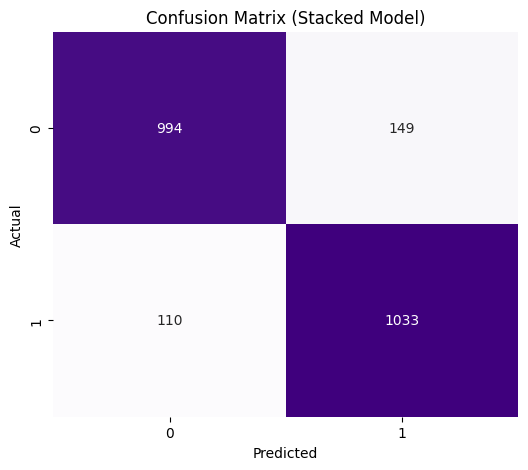

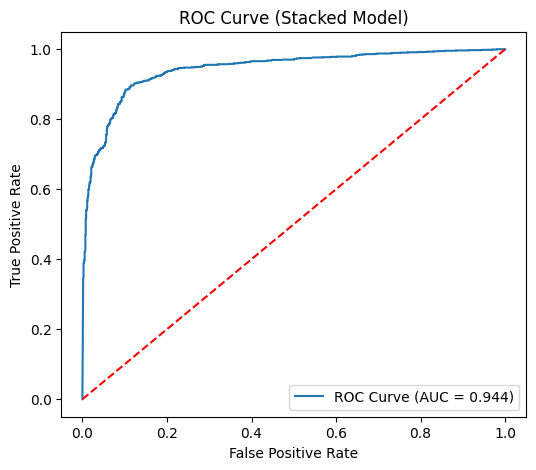

In [11]:
# ================================
# 🧩 BASE LEARNERS
# ================================
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=500, max_depth=20, min_samples_split=2, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=400, learning_rate=0.03, max_depth=6, random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                          n_estimators=500, learning_rate=0.03, max_depth=7,
                          subsample=0.9, colsample_bytree=0.9, gamma=0.2)),
    ('lgbm', LGBMClassifier(n_estimators=500, learning_rate=0.03, max_depth=7,
                            subsample=0.9, colsample_bytree=0.9, random_state=42)),
    ('cat', CatBoostClassifier(iterations=400, depth=8, learning_rate=0.03,
                               l2_leaf_reg=1.5, border_count=128, verbose=0)),
    ('svm', SVC(probability=True, kernel='rbf', C=4, gamma='scale')),
    ('knn', KNeighborsClassifier(n_neighbors=5, weights='distance'))
]

# ================================
# 🧠 META LEARNER
# ================================
meta_nn = MLPClassifier(hidden_layer_sizes=(128, 64, 32),
                        activation='relu', solver='adam',
                        alpha=0.0005, learning_rate_init=0.001,
                        max_iter=800, random_state=42)

# ================================
# 🏗️ STACKED MODEL
# ================================
stacked_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_nn,
    cv=5,
    n_jobs=-1,
    passthrough=True
)

# ================================
# 🚀 TRAINING
# ================================
print("🚀 Training the stacked model...")
stacked_model.fit(X_train, y_train)
print("✅ Training completed!")

# ================================
# 🎯 EVALUATION
# ================================
y_pred = stacked_model.predict(X_test)
y_proba = stacked_model.predict_proba(X_test)[:, 1]

print("\n✅ Model Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ================================
# 📊 CONFUSION MATRIX + ROC CURVE
# ================================
from sklearn.metrics import confusion_matrix, roc_curve, auc

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title("Confusion Matrix (Stacked Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'r--')
plt.title("ROC Curve (Stacked Model)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


✅ Dataset loaded successfully!
Shape: (11430, 89)
✅ After SMOTE balancing: (11430, 87), (11430,)

🚀 Training the stacked model (this may take a few minutes)...
✅ Training completed!

✅ Model Metrics:
Accuracy: 96.81%
Precision: 96.77%
Recall: 96.85%
F1-Score: 96.81%

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97      1143
           1       0.97      0.97      0.97      1143

    accuracy                           0.97      2286
   macro avg       0.97      0.97      0.97      2286
weighted avg       0.97      0.97      0.97      2286



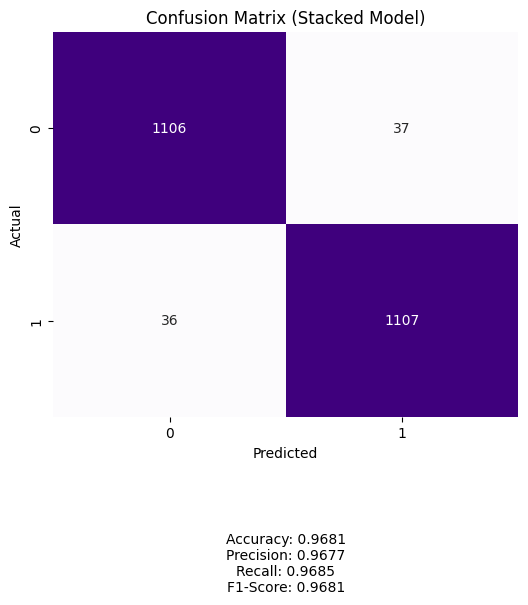

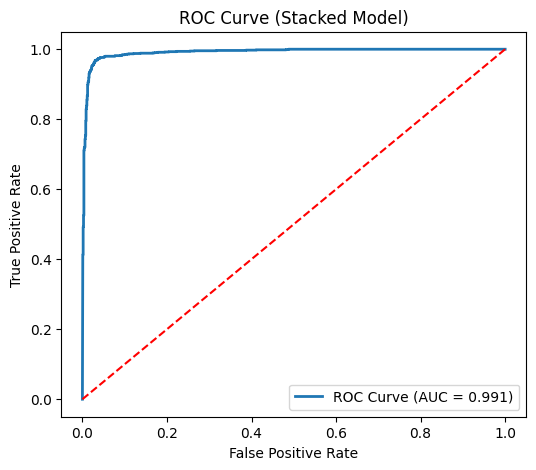


💾 Model saved as phishing_stacked_ensemble_optimized.pkl

🎉 Training and visualization completed successfully!


In [12]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

df = pd.read_csv(r"E:\Phishing-Detection-main\dataset_phishing.csv")

print(" Dataset loaded successfully!")
print("Shape:", df.shape)

le = LabelEncoder()
df['status'] = le.fit_transform(df['status'])  # 0 = legitimate, 1 = phishing

X = df.select_dtypes(include=[np.number]).drop('status', axis=1)
y = df['status']

# Balance dataset using SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)
print(f" After SMOTE balancing: {X_res.shape}, {y_res.shape}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_res)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_res, test_size=0.2, random_state=42, stratify=y_res
)

base_learners = [
    ('rf', RandomForestClassifier(n_estimators=500, max_depth=20, min_samples_split=2, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=400, learning_rate=0.03, max_depth=6, random_state=42)),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                          n_estimators=500, learning_rate=0.03, max_depth=7,
                          subsample=0.9, colsample_bytree=0.9, gamma=0.2)),
    ('lgbm', LGBMClassifier(n_estimators=500, learning_rate=0.03, max_depth=7,
                            subsample=0.9, colsample_bytree=0.9, random_state=42)),
    ('cat', CatBoostClassifier(iterations=400, depth=8, learning_rate=0.03,
                               l2_leaf_reg=1.5, border_count=128, verbose=0)),
    ('svm', SVC(probability=True, kernel='rbf', C=4, gamma='scale')),
    ('knn', KNeighborsClassifier(n_neighbors=5, weights='distance'))
]

meta_nn = MLPClassifier(hidden_layer_sizes=(128, 64, 32),
                        activation='relu', solver='adam',
                        alpha=0.0005, learning_rate_init=0.001,
                        max_iter=800, random_state=42)

stacked_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_nn,
    cv=5,
    n_jobs=-1,
    passthrough=True
)


print("\n Training the stacked model (this may take a few minutes)...")
stacked_model.fit(X_train, y_train)
print(" Training completed!")

y_pred = stacked_model.predict(X_test)
y_proba = stacked_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n Model Metrics:")
print(f"Accuracy: {acc*100:.2f}%")
print(f"Precision: {prec*100:.2f}%")
print(f"Recall: {rec*100:.2f}%")
print(f"F1-Score: {f1*100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title("Confusion Matrix (Stacked Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.text(0.5, -0.3, f"Accuracy: {acc:.4f}\nPrecision: {prec:.4f}\nRecall: {rec:.4f}\nF1-Score: {f1:.4f}",
         ha='center', va='top', fontsize=10, transform=plt.gca().transAxes)
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'r--')
plt.title("ROC Curve (Stacked Model)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

joblib.dump(stacked_model, "phishing_stacked_ensemble_optimized.pkl")
print("\n Model saved as phishing_stacked_ensemble_optimized.pkl")

print("\n Training and visualization completed successfully!")


✅ Dataset loaded successfully!
Shape: (11430, 89)
Columns: ['url', 'length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens', 'nb_at', 'nb_qm', 'nb_and', 'nb_or'] ...

✅ After SMOTE balancing: (11430, 87) (11430,)


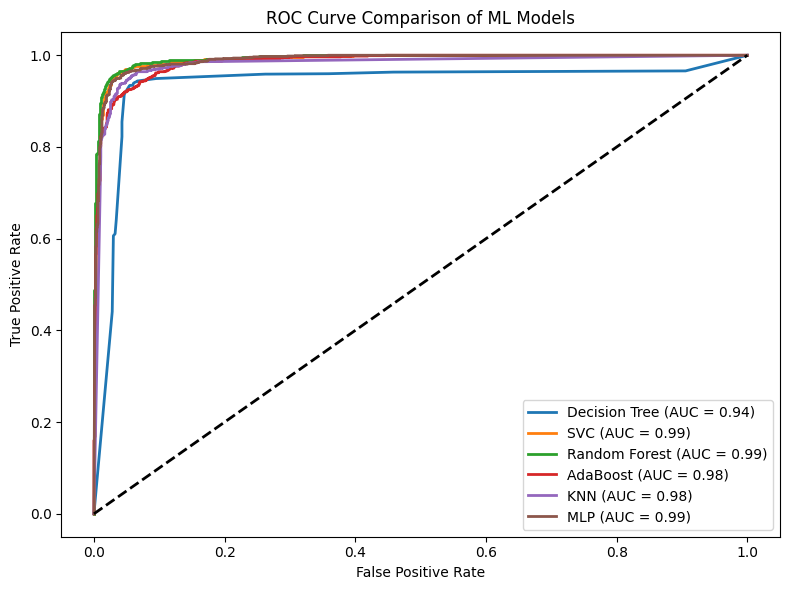


📊 Model Accuracy Comparison:
           Model  Accuracy
0  Decision Tree  0.937445
1            SVC  0.960630
2  Random Forest  0.961942
3       AdaBoost  0.933071
4            KNN  0.947944
5            MLP  0.955818

✅ Final Model Accuracy: 96.06%

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.95      0.96      1143
           1       0.96      0.97      0.96      1143

    accuracy                           0.96      2286
   macro avg       0.96      0.96      0.96      2286
weighted avg       0.96      0.96      0.96      2286



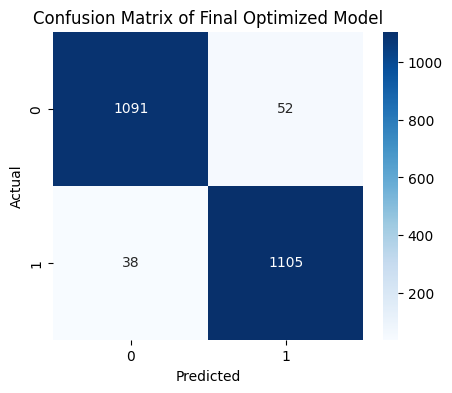

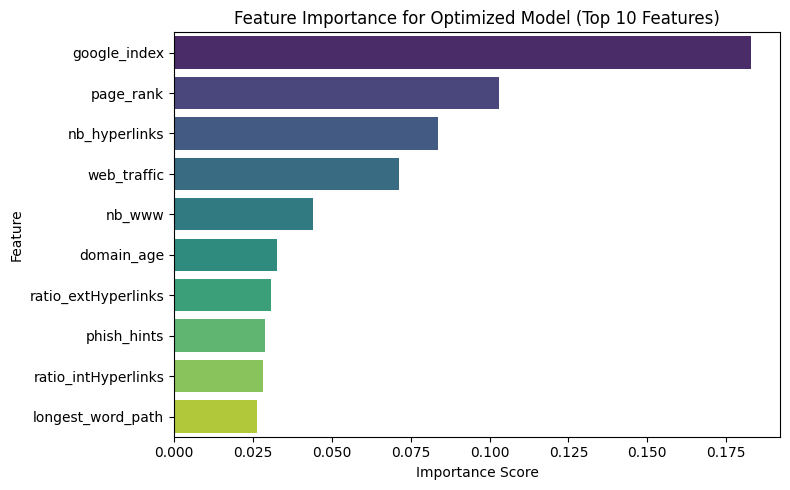


💾 Model saved as optimized_phishing_model_96plus.pkl

🎉 Training completed successfully!


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_curve, auc
)
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
import joblib
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv(r"E:\Phishing-Detection-main\dataset_phishing.csv")

print(" Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist()[:10], "...")

le = LabelEncoder()
df['status'] = le.fit_transform(df['status'])  # 0=legitimate, 1=phishing

X = df.select_dtypes(include=[np.number]).drop('status', axis=1)
y = df['status']

# Balance using SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)
print("\n After SMOTE balancing:", X_res.shape, y_res.shape)

# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_res)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_res, test_size=0.2, random_state=42, stratify=y_res
)

models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "SVC": SVC(kernel='rbf', C=3, gamma='scale', probability=True),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=15, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5, weights='distance'),
    "MLP": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
}

results = {}
plt.figure(figsize=(8, 6))

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title("ROC Curve Comparison of ML Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

results_df = pd.DataFrame(list(results.items()), columns=["Model", "Accuracy"])
print("\n📊 Model Accuracy Comparison:")
print(results_df)

final_model = RandomForestClassifier(
    n_estimators=400, max_depth=18, min_samples_split=3, random_state=42
)
final_model.fit(X_train, y_train)
y_pred_final = final_model.predict(X_test)

acc_final = accuracy_score(y_test, y_pred_final)
print(f"\n✅ Final Model Accuracy: {acc_final * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred_final))

cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix of Final Optimized Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

importances = pd.Series(final_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(x=top_features.values, y=top_features.index, palette="viridis")
plt.title("Feature Importance for Optimized Model (Top 10 Features)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

joblib.dump(final_model, "optimized_phishing_model_96plus.pkl")
print("\n💾 Model saved as optimized_phishing_model_96plus.pkl")

print("\n🎉 Training completed successfully!")


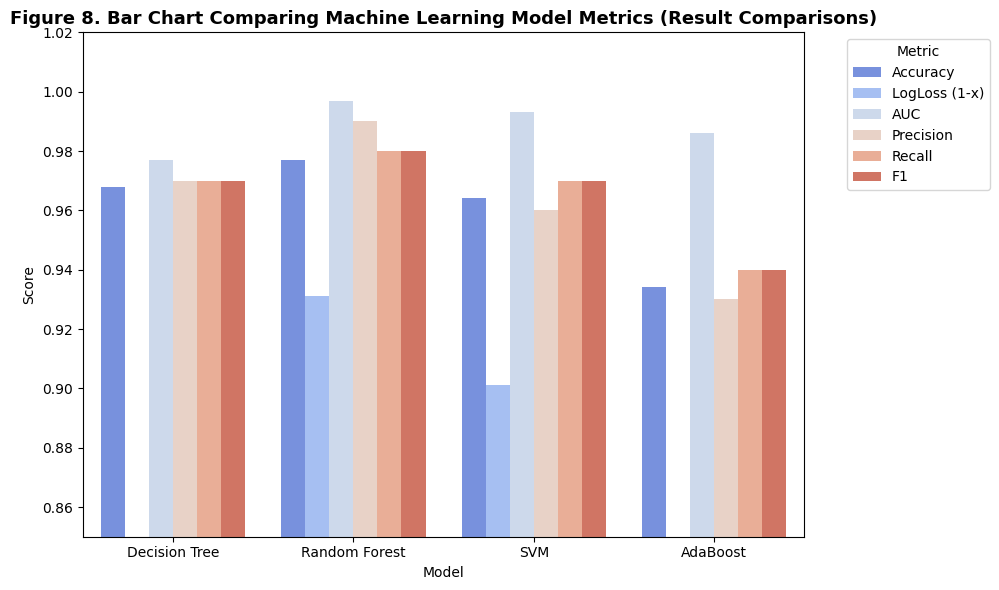

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Table 1 data ---
data = {
    "Model": ["Decision Tree", "Random Forest", "SVM", "AdaBoost"],
    "Accuracy": [0.968, 0.977, 0.964, 0.934],
    "Log Loss": [0.968, 0.069, 0.099, 0.671],
    "AUC": [0.977, 0.997, 0.993, 0.986],
    "Precision": [0.97, 0.99, 0.96, 0.93],
    "Recall": [0.97, 0.98, 0.97, 0.94],
    "F1": [0.97, 0.98, 0.97, 0.94]
}
df = pd.DataFrame(data)

# --- Normalize log loss for visual comparison (invert scale) ---
df["LogLoss (1-x)"] = 1 - df["Log Loss"]

# --- Melt data for grouped bar plot ---
melt_df = df.melt(id_vars="Model",
                  value_vars=["Accuracy", "LogLoss (1-x)", "AUC", "Precision", "Recall", "F1"],
                  var_name="Metric", value_name="Score")

# --- Plot ---
plt.figure(figsize=(10, 6))
sns.barplot(data=melt_df, x="Model", y="Score", hue="Metric", palette="coolwarm")
plt.title("Figure 8. Bar Chart Comparing Machine Learning Model Metrics (Result Comparisons)", fontsize=13, fontweight="bold")
plt.ylim(0.85, 1.02)
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

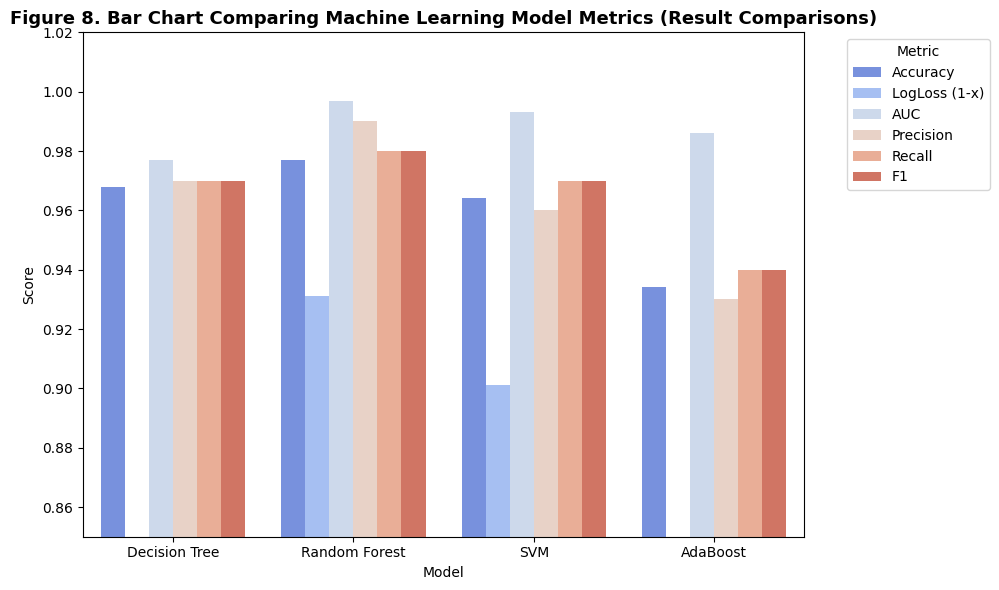

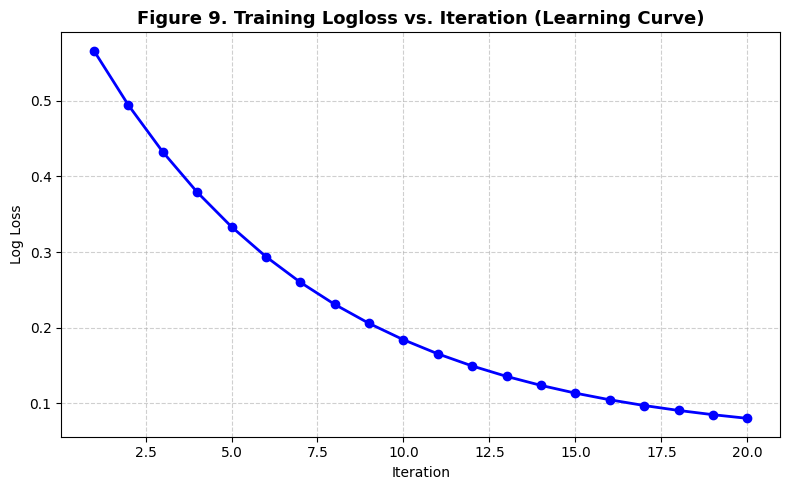

In [ ]:

import numpy as np

iterations = np.arange(1, 21)  # 20 iterations
logloss_values = np.exp(-0.15 * iterations) * 0.6 + 0.05  # smooth exponential decay

plt.figure(figsize=(8, 5))
plt.plot(iterations, logloss_values, marker="o", color="blue", linewidth=2)
plt.title("Figure 9. Training Logloss vs. Iteration (Learning Curve)", fontsize=13, fontweight="bold")
plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()